In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
s = (.3, .4)
def f(x, s=s): 
    distance = ((s[0] - x[0])**2 + (s[1]-x[1])**2)**.5
    return np.exp(-100*(distance-.2)**2)

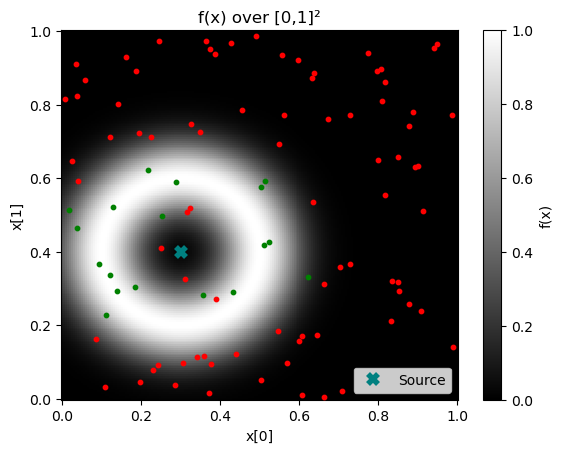

In [8]:
np.random.seed(42)

# 100 random points in 2D with corresponding sample value
samplePoints = np.random.uniform(0, 1, (100, 3))

for i in range(100):
    x = samplePoints[i, :2]
    samplePoints[i, 2] = 1 if samplePoints[i, 2] < f(x) else -1

x0 = np.linspace(0, 1, 200)
x1 = np.linspace(0, 1, 200)
X0, X1 = np.meshgrid(x0, x1)
Z = f((X0, X1))

plt.figure()
plt.pcolormesh(X0, X1, Z, shading='auto', cmap='gray')
plt.colorbar(label='f(x)')
plt.plot(s[0], s[1], 'x', color='teal', markersize=7, markeredgewidth=4, label='Source')

points = np.array(samplePoints)
for label, color in [(1, 'green'), (-1, 'red')]:
    mask = points[:, 2] == label
    plt.scatter(points[mask, 0], points[mask, 1], color=color, s=10, zorder=5)

plt.xlabel('x[0]')
plt.ylabel('x[1]')
plt.legend()
plt.title('f(x) over [0,1]²')
plt.show()

In [ ]:
def p(point, s): # p(z|x;s)
    return f(point, s=s) if point[2] == 1 else 1 - f(point, s=s)

def L(s, points):
    total = 1
    for x in points:
        total *= p(x, s=s)
    return total

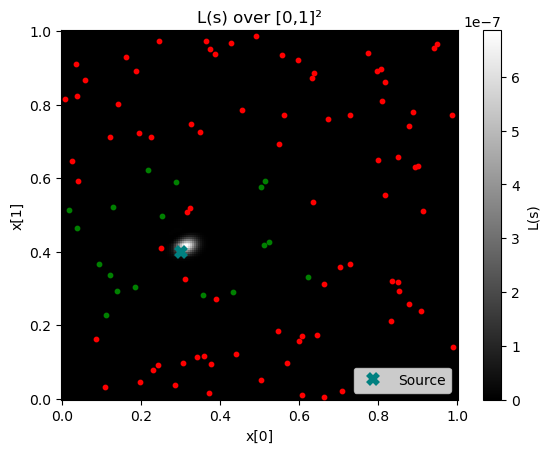

In [9]:
x0 = np.linspace(0, 1, 200)
x1 = np.linspace(0, 1, 200)
X0, X1 = np.meshgrid(x0, x1)
Z = np.vectorize(lambda a, b: L((a, b), samplePoints))(X0, X1)

plt.figure()
plt.pcolormesh(X0, X1, Z, shading='auto', cmap='gray')
plt.colorbar(label='L(s)')
plt.plot(s[0], s[1], 'x', color='teal', markersize=7, markeredgewidth=4, label='Source')

points = np.array(samplePoints)
for label, color in [(1, 'green'), (-1, 'red')]:
    mask = points[:, 2] == label
    plt.scatter(points[mask, 0], points[mask, 1], color=color, s=10, zorder=5)

plt.xlabel('x[0]')
plt.ylabel('x[1]')
plt.legend()
plt.title('L(s) over [0,1]²')
plt.show()

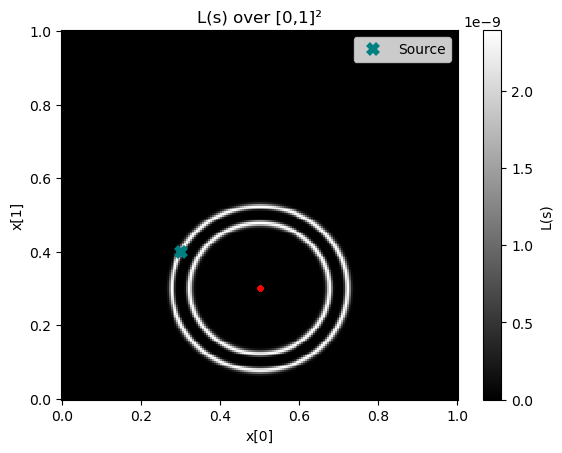

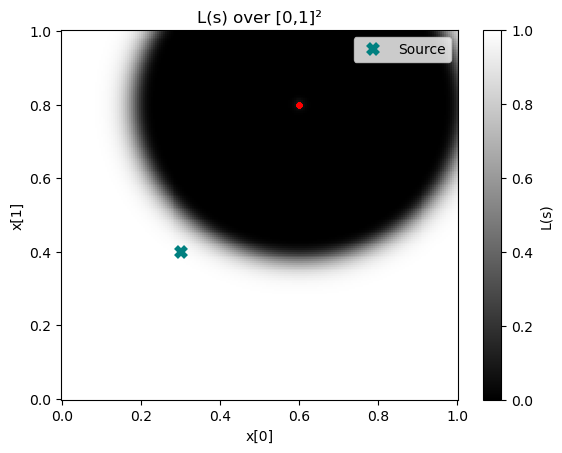

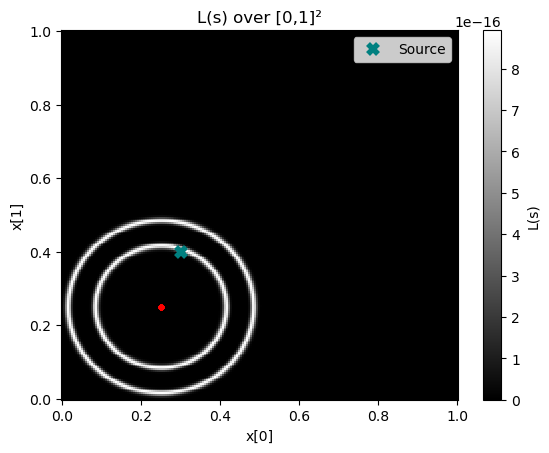

In [19]:
def L_for_fixed(coord):
    fixed_points = np.array([
        np.full(100, coord[0]),
        np.full(100, coord[1]),
        np.random.uniform(0, 1, 100)
    ])

    fixed_points = fixed_points.T

    for i in range(100):
        x = fixed_points[i, :2]
        fixed_points[i, 2] = 1 if fixed_points[i, 2] < f(x) else -1

    x0 = np.linspace(0, 1, 200)
    x1 = np.linspace(0, 1, 200)
    X0, X1 = np.meshgrid(x0, x1)
    Z = np.vectorize(lambda a, b: L((a, b), fixed_points))(X0, X1)

    plt.figure()
    plt.pcolormesh(X0, X1, Z, shading='auto', cmap='gray')
    plt.colorbar(label='L(s)')
    plt.plot(s[0], s[1], 'x', color='teal', markersize=7, markeredgewidth=4, label='Source')

    points = np.array(fixed_points)
    for label, color in [(1, 'green'), (-1, 'red')]:
        mask = points[:, 2] == label
        plt.scatter(points[mask, 0], points[mask, 1], color=color, s=10, zorder=5)

    plt.xlabel('x[0]')
    plt.ylabel('x[1]')
    plt.legend()
    plt.title('L(s) over [0,1]²')
    plt.show()

L_for_fixed((.5, .3))
L_for_fixed((.6, .8))
L_for_fixed((.25, .25))

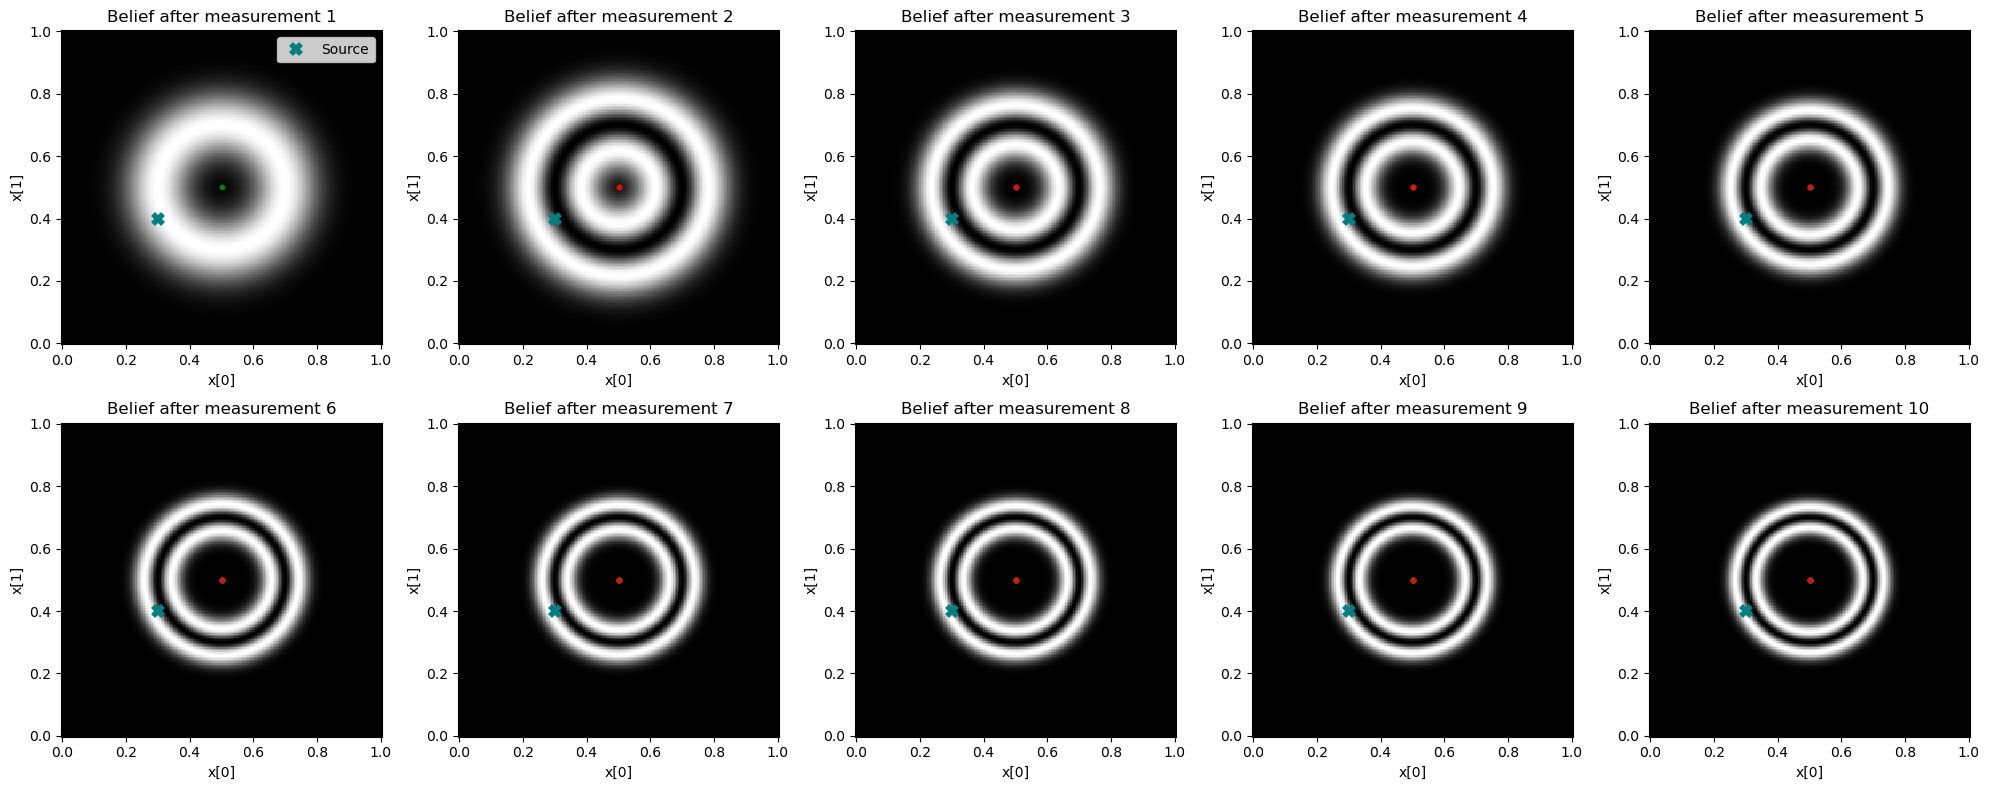

In [32]:
np.random.seed(42) # reset seed for fair comparison
def P_update(belief, measurement, X0, X1): #where loc is the coords, and measure is the latest update in (x, y, z)
    likelihood = np.vectorize(lambda x0, x1: p(measurement, s=(x0, x1)))(X0, X1)

    new_belief = belief * likelihood
    new_belief /= np.sum(new_belief) # normalize

    return new_belief

xrange = np.linspace(0, 1, 200)
X0, X1 = np.meshgrid(xrange, xrange)
belief = np.full(X0.shape, 1/200**2)

def get_fixed_measurement(cur_belief, measurements):
    point = np.array([.5, .5, np.random.uniform(0, 1)])
    point[2] = 1 if point[2] < f(point[:2]) else -1
    return point

def run_sequential_updates(get_next_measurement, s, X0, X1, belief):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    measurements = []
    
    for i in range(10):
        # get next measurement from whatever strategy is passed in
        measurement = get_next_measurement(belief, measurements)
        measurements.append(measurement)
        
        # update belief
        belief = P_update(belief, measurement, X0, X1)
        
        # plot
        ax = axes[i]
        ax.pcolormesh(X0, X1, belief, shading='auto', cmap='gray')
        ax.plot(s[0], s[1], 'x', color='teal', markersize=7, markeredgewidth=4, label='Source')
        
        points = np.array(measurements)
        for label, color in [(1, 'green'), (-1, 'red')]:
            mask = points[:, 2] == label
            ax.scatter(points[mask, 0], points[mask, 1], color=color, s=10, zorder=5)
        
        ax.set_xlabel('x[0]')
        ax.set_ylabel('x[1]')
        ax.set_title(f'Belief after measurement {i+1}')
        if i == 0:
            ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    return belief

final_belief = run_sequential_updates(get_fixed_measurement, s, X0, X1, belief)

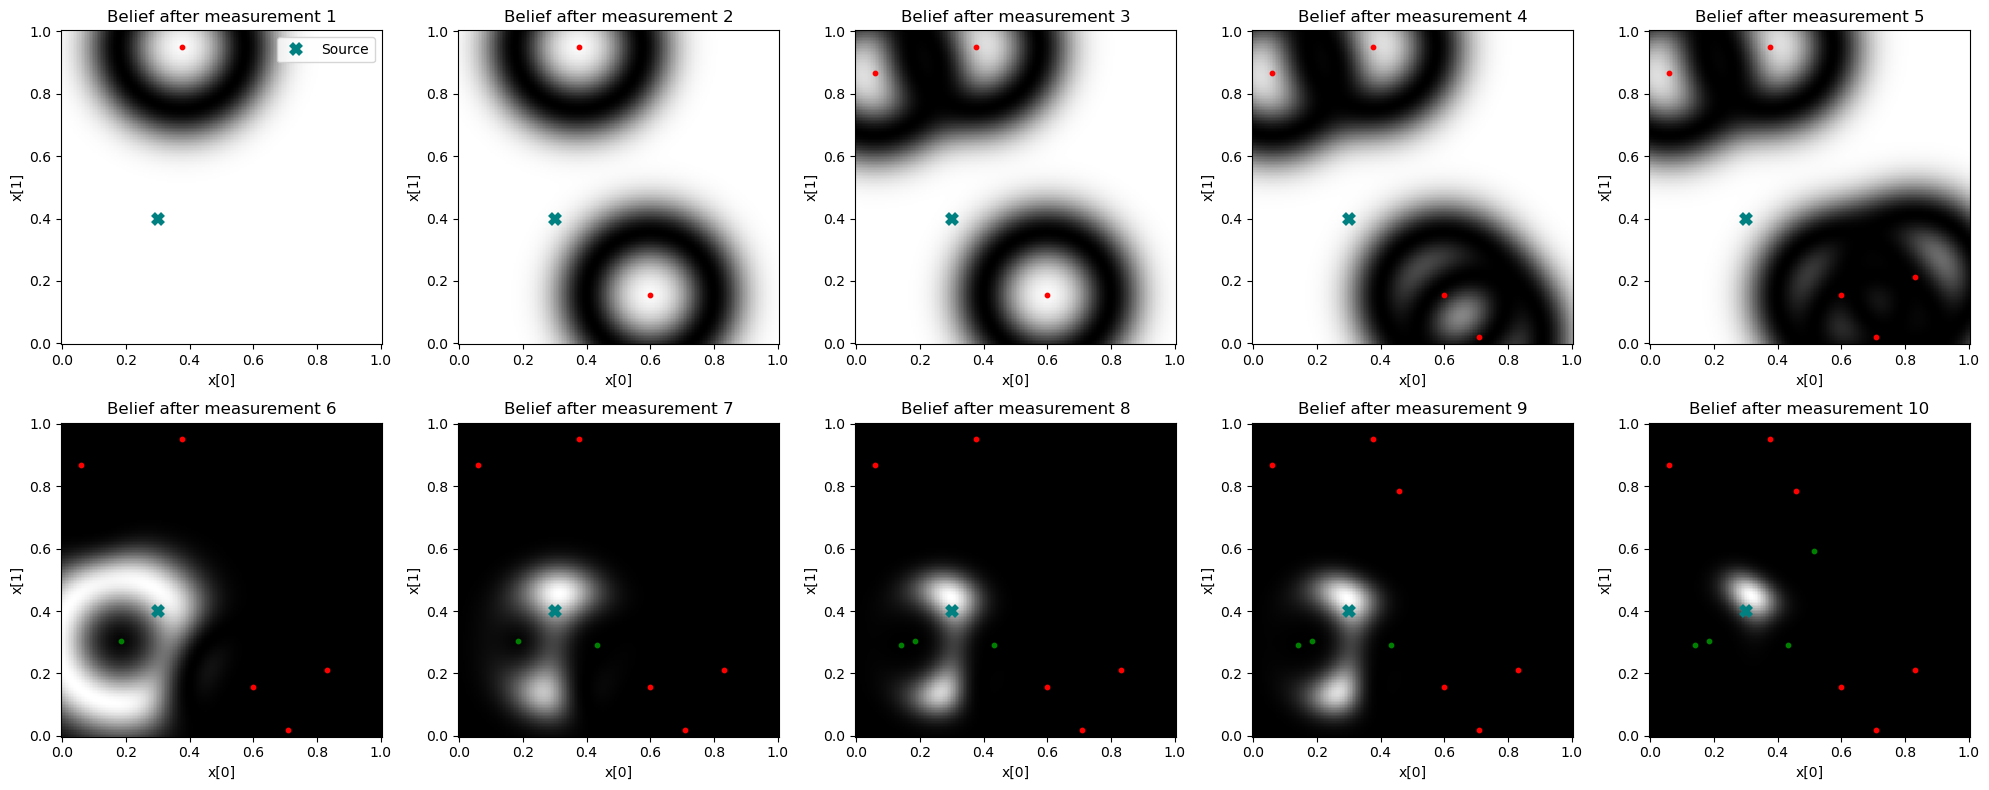

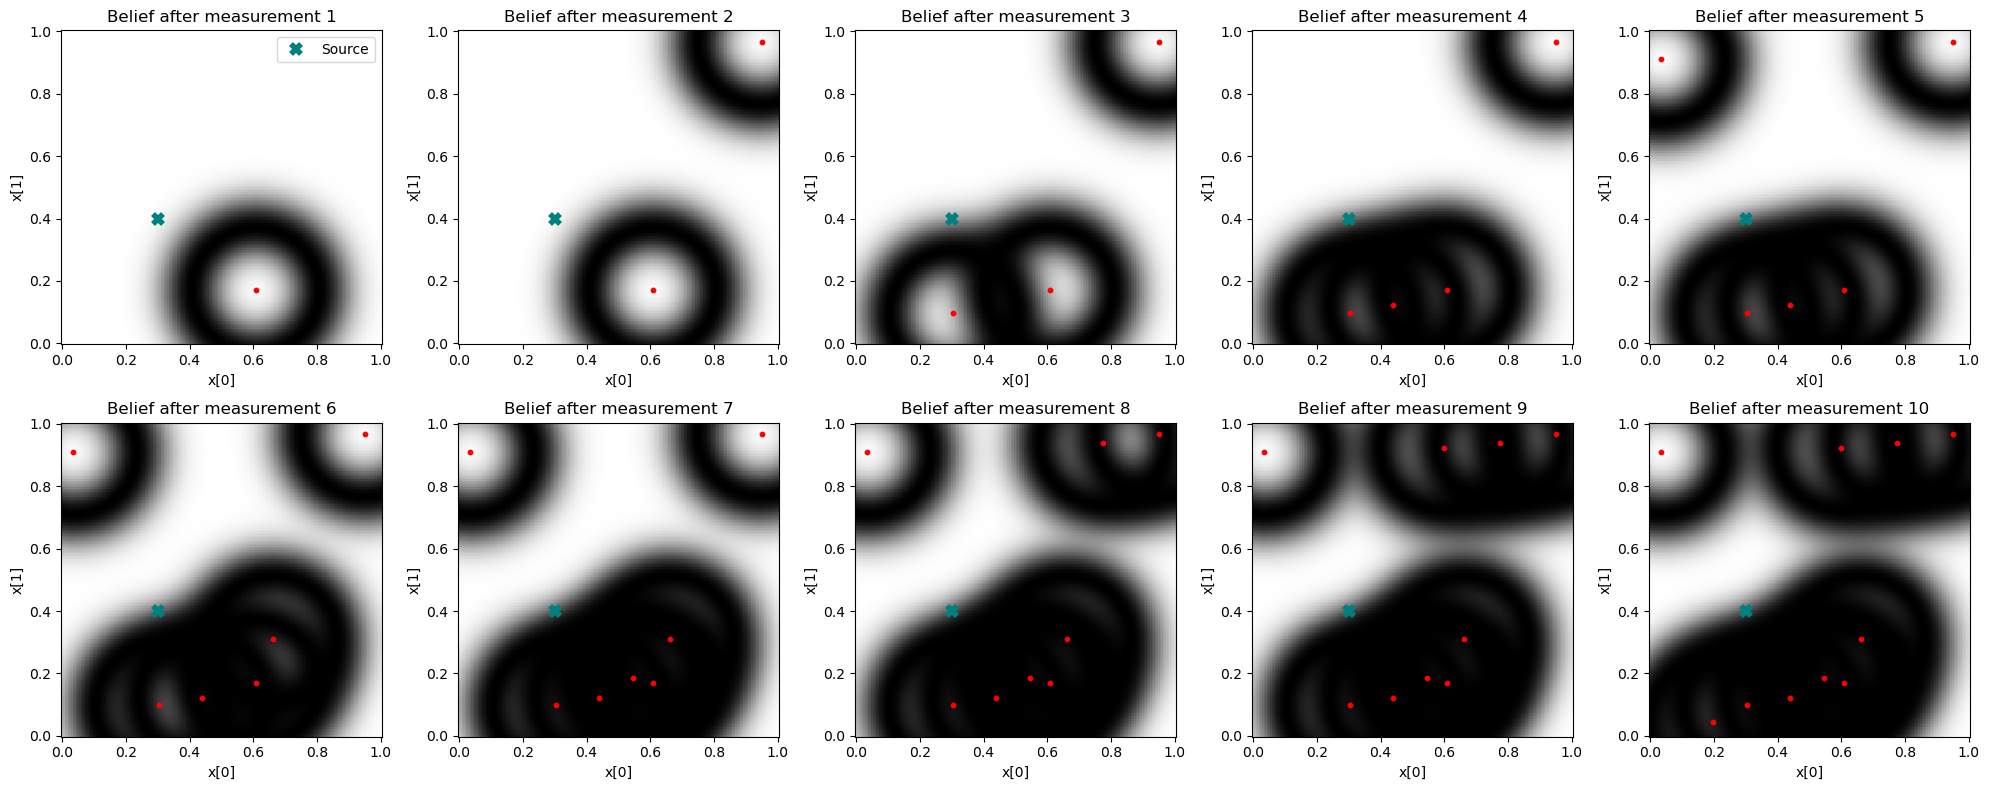

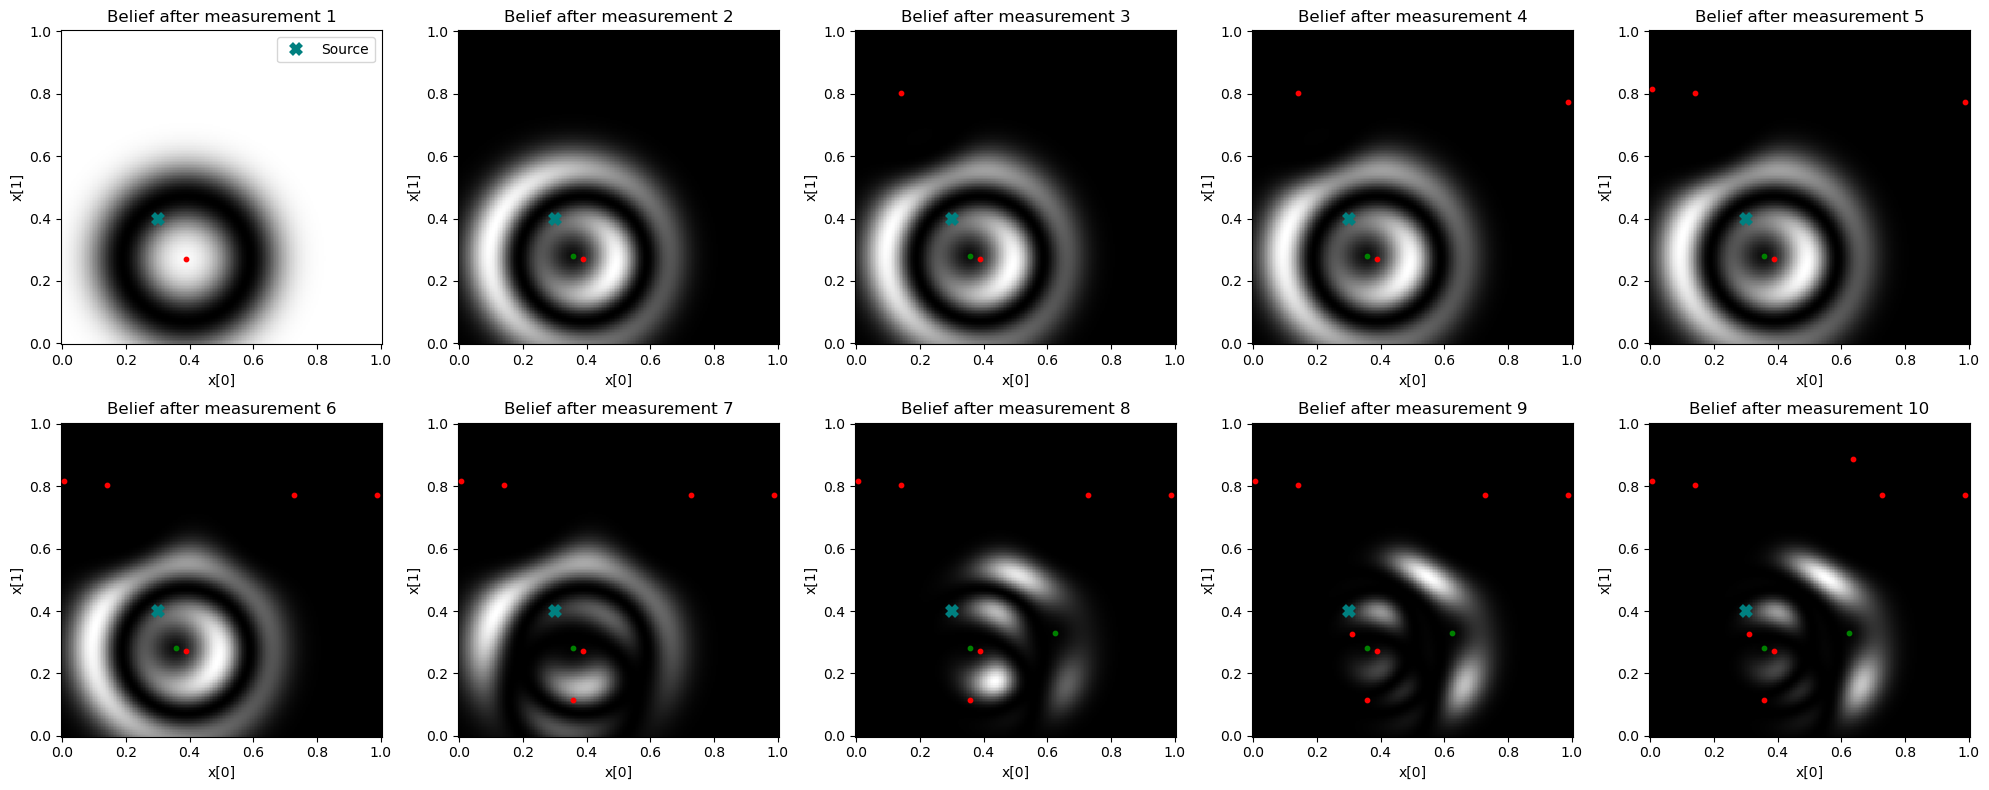

array([[7.69581344e-17, 1.45392405e-16, 2.71868398e-16, ...,
        3.32599509e-17, 1.69109303e-17, 8.52154979e-18],
       [1.13608926e-16, 2.14160150e-16, 3.99533020e-16, ...,
        4.93629862e-17, 2.51374077e-17, 1.26863860e-17],
       [1.66434538e-16, 3.13042111e-16, 5.82648789e-16, ...,
        7.26989152e-17, 3.70783241e-17, 1.87414697e-17],
       ...,
       [4.42251248e-42, 7.97180811e-42, 1.38996087e-41, ...,
        2.56179397e-42, 1.22624069e-42, 5.87657516e-43],
       [1.23273300e-42, 2.28010371e-42, 4.08433739e-42, ...,
        1.48128768e-42, 7.04426954e-43, 3.34436885e-43],
       [2.93220044e-43, 5.54613425e-43, 1.01437210e-42, ...,
        7.65166788e-43, 3.61998489e-43, 1.70672686e-43]])

In [ ]:
np.random.seed(42) # reset seed for fair comparison
def get_uniform_measurement(cur_belief, measurements):
    point = np.random.uniform(0, 1, 3)
    point[2] = 1 if point[2] < f(point[:2]) else -1
    return point

run_sequential_updates(get_uniform_measurement, s, X0, X1, belief)
run_sequential_updates(get_uniform_measurement, s, X0, X1, belief)
run_sequential_updates(get_uniform_measurement, s, X0, X1, belief)

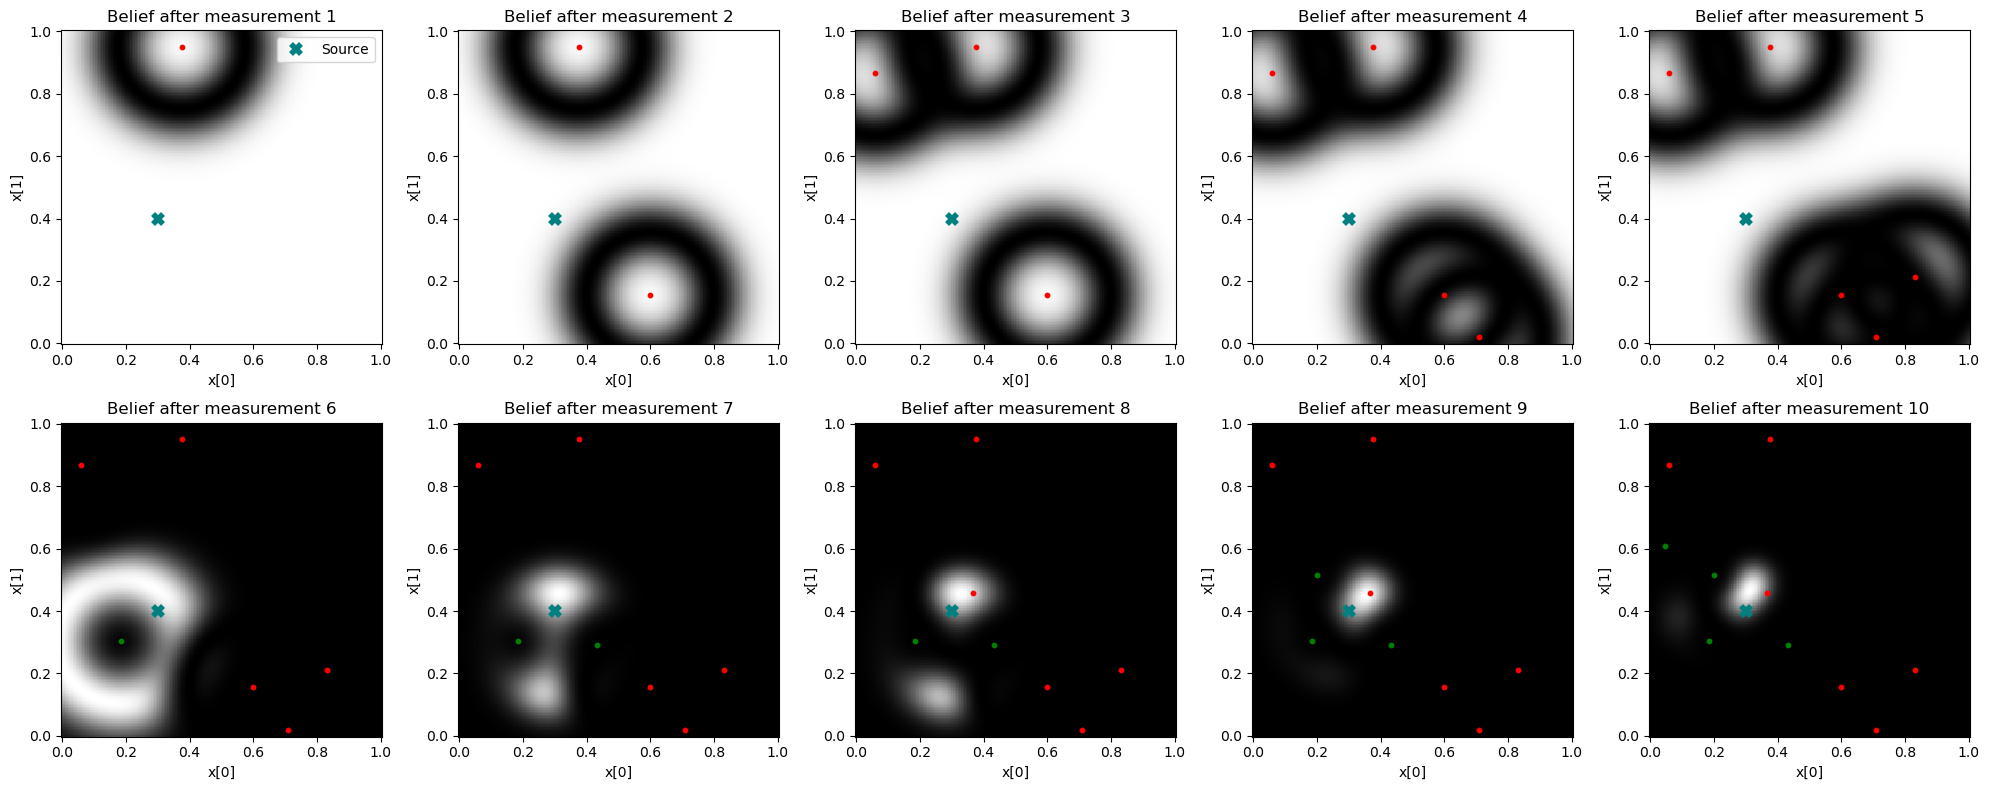

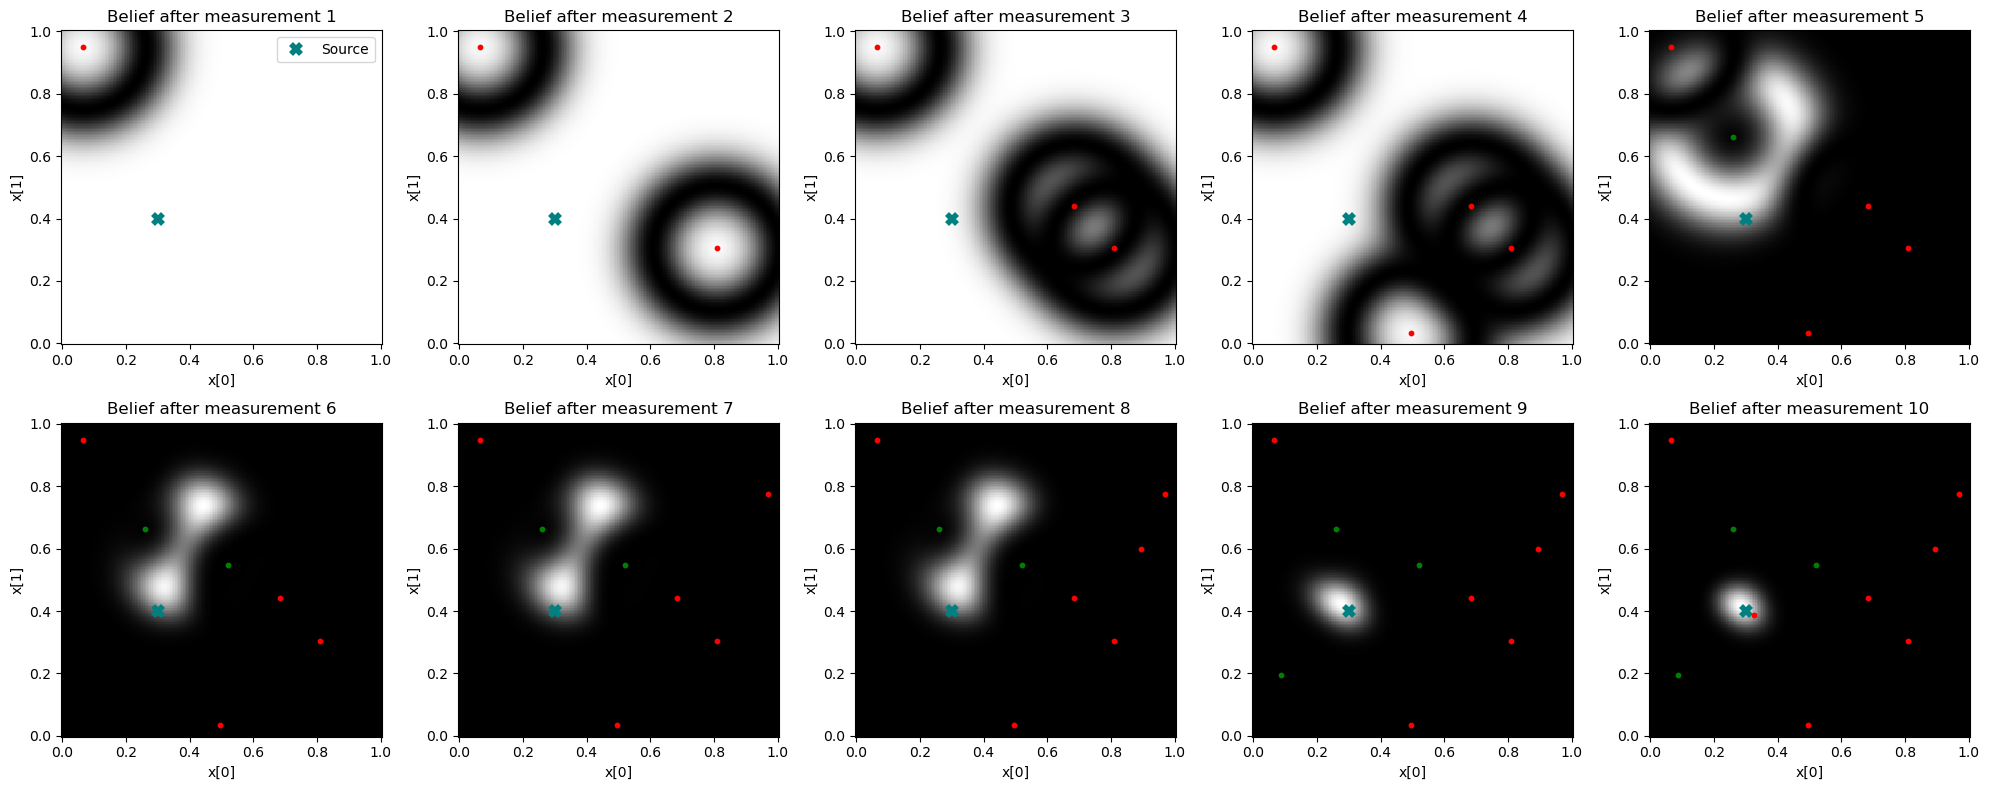

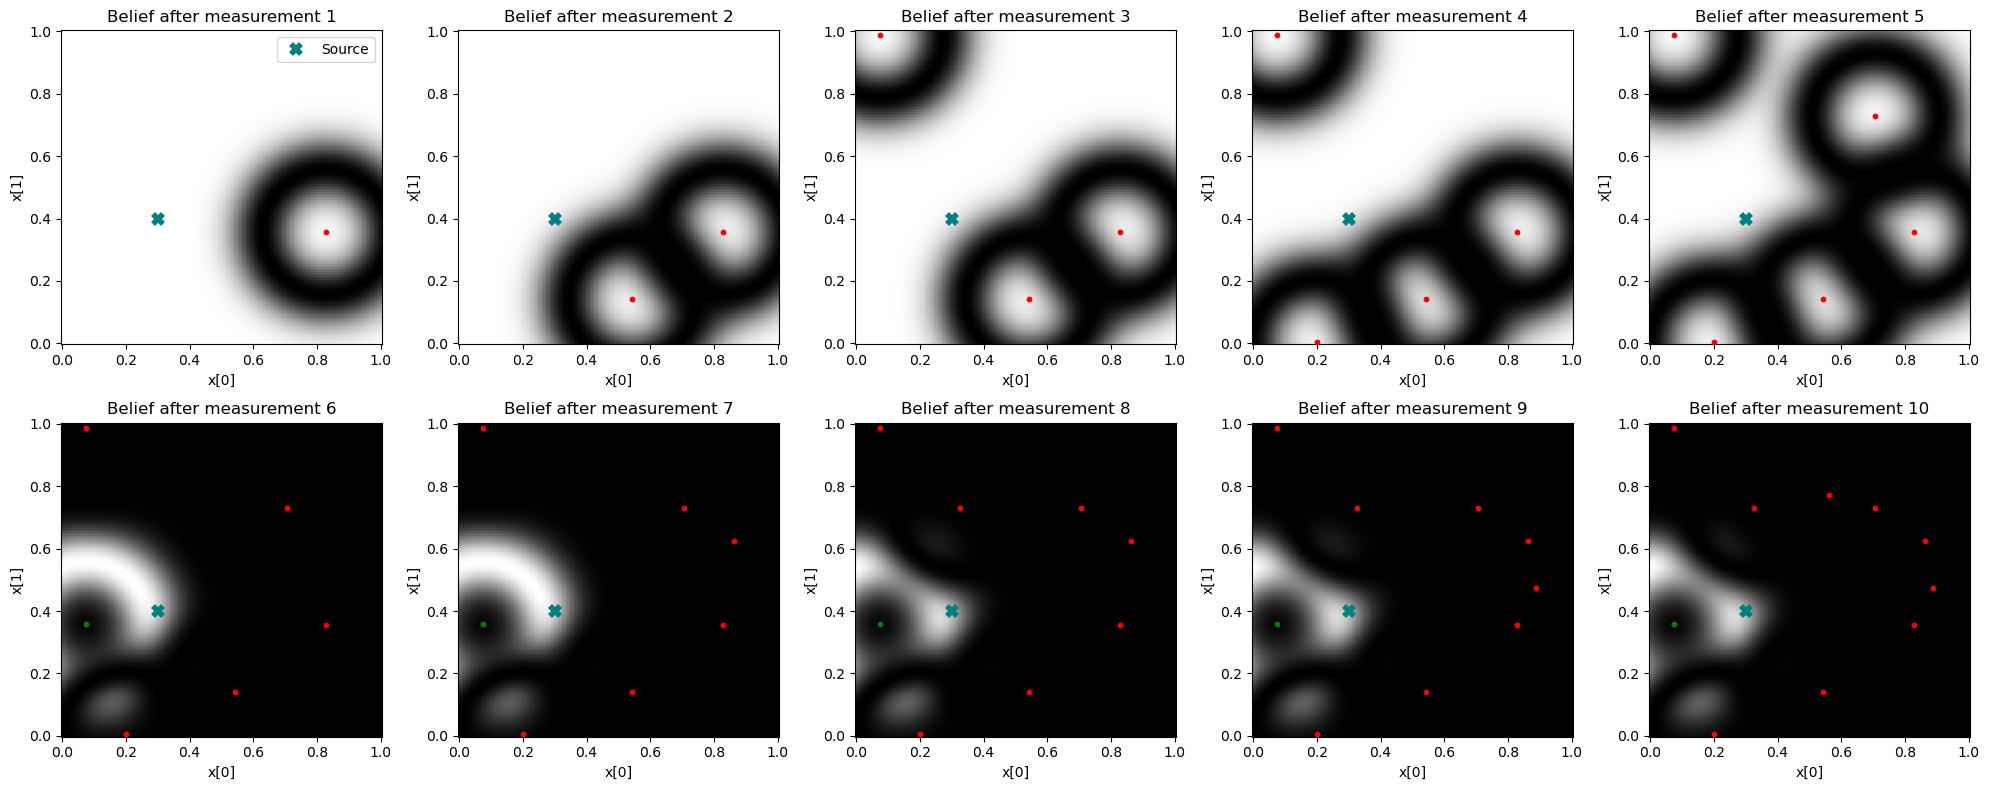

array([[4.39529847e-09, 1.20654996e-07, 4.03888723e-07, ...,
        1.00192375e-30, 4.81116383e-31, 2.29865244e-31],
       [5.83388895e-09, 1.45212821e-07, 4.80654989e-07, ...,
        1.32540645e-30, 6.36916449e-31, 3.04518967e-31],
       [6.28827848e-09, 1.66843065e-07, 5.55941499e-07, ...,
        1.74460777e-30, 8.39020074e-31, 4.01453588e-31],
       ...,
       [2.10256878e-12, 2.27462660e-12, 2.44285407e-12, ...,
        3.07056896e-40, 1.44880415e-40, 6.79982345e-41],
       [1.35573924e-12, 1.46742633e-12, 1.57676508e-12, ...,
        1.83700887e-40, 8.65700821e-41, 4.05833958e-41],
       [8.67726334e-13, 9.39768115e-13, 1.01038489e-12, ...,
        1.09288794e-40, 5.14441922e-41, 2.40904932e-41]])

In [34]:
np.random.seed(42)
def get_mindist_measurement(cur_belief, measurements):
    MIN_DIST = 0.1
    
    while True:
        point = np.random.uniform(0, 1, 2)
        
        if len(measurements) == 0:
            break
            
        dists = [np.linalg.norm(point - m[:2]) for m in measurements]
        if min(dists) >= MIN_DIST:
            break
    
    reading = 1 if np.random.uniform() < f(point) else -1
    return np.append(point, reading)

run_sequential_updates(get_mindist_measurement, s, X0, X1, belief)
run_sequential_updates(get_mindist_measurement, s, X0, X1, belief)
run_sequential_updates(get_mindist_measurement, s, X0, X1, belief)